# Imports

In [345]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as ss

# Funções

In [346]:
def cramer_v( x, y ): 
    cm = pd.crosstab( x, y ).values
    n = cm.sum() 
    r, k = cm.shape 
    chi2 = ss.chi2_contingency( cm )[0] 
    chi2corr = max( 0, chi2 - (k-1)*(r-1)/(n-1) ) 
    kcorr = k - (k-1)**2/(n-1) 
    rcorr = r - (r-1)**2/(n-1) 

    return np.sqrt((chi2corr/n)/( min( kcorr-1, rcorr-1)))

# Loading Dataset

In [347]:
df = pd.read_excel('dataset/dataset_leite_realista.xlsx')

# Analisando os Dados

In [348]:
df.head().T

drop = ['index', 'Breed', 'Country', 'Climate_Zone', 'Management_System', 'Feed_Type', 'Feeding_Frequency', 'FMD_Vaccine', 'Brucellosis_Vaccine', 'Lot_ID', 'Milking_Interval_hrs', 'Grazing_Duration_hrs', 'Farm_ID', 'Housing_Score']

nome coluna: Health_Event_Day

mudança: Eu recomendaria Days_In_Health_Event: 0 para animais saudáveis e 1, 2, 3... durante o episódio. Isso fica mais intuitivo e evita usar -1.

In [349]:
#ajustando alguns dados e colunas
df1 = df.copy()

df1 = df1.rename(columns=({
    'Days_Since_Health_Event': 'Health_Event_Day'
}))

#df['sexo'] = df['sexo'].map({'M': 'Macho', 'F': 'Fêmea'})
#df['peso_kg'] = df['peso_lb'].map(lambda x: x * 0.453592)

df1['Health_Event_Day'] = df1['Health_Event_Day'].map(lambda x: x + 1)
df1['Heat_Stress_Level'] = df1['Heat_Stress_Level'].map(lambda x: 'Without' if pd.isna(x) else x)

df2 = df1.drop(drop, axis=1)
df2.head().T

,0,1,2,3,4
Cattle_ID,CATTLE_0001,CATTLE_0002,CATTLE_0003,CATTLE_0004,CATTLE_0005
Age_Months,58.6,80.7,50.8,88.6,57.2
Weight_kg,648.7,633.7,644.5,567.7,653.4
Parity,3,5,3,5,3
Lactation_Stage,Early,Early,Early,Early,Mid
Days_in_Milk,50,55,20,81,137
Feed_Quantity_kg,25.85,22.88,22.72,20.29,22.39
Water_Intake_L,69.0,72.8,64.6,56.2,72.7
Walking_Distance_km,1.39,0.59,0.54,0.8,0.41
Rumination_Time_hrs,8.56,7.99,7.64,7.79,7.75


In [350]:
#criando novas features

df2.dtypes
df2['Desvio'] = df2['Milk_Yield_L'] - df2['Previous_Week_Avg_Yield']

df2['Milk_Mean_15_Days_Ago'] = (
    df2.groupby('Cattle_ID')['Milk_Yield_L']
      .transform(lambda x: x.shift(1).rolling(15).mean())
)

df2['Milk_Yield_L_15_Days_from_now'] = df2.groupby('Cattle_ID')['Milk_Yield_L'].shift(-15)

df2 = df2.dropna(subset=['Milk_Mean_15_Days_Ago'])
df2 = df2.dropna(subset=['Milk_Yield_L_15_Days_from_now'])

In [351]:
df2.loc[df2['Cattle_ID'] == 'CATTLE_0001', :].tail(20).T

,10260,10440,10620,10800,10980,11160,11340,11520,11700,11880,12060,12240,12420,12600,12780,12960,13140,13320,13500,13680
Cattle_ID,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001
Age_Months,60.5,60.5,60.6,60.6,60.6,60.7,60.7,60.7,60.8,60.8,60.8,60.9,60.9,60.9,61.0,61.0,61.0,61.1,61.1,61.1
Weight_kg,643.6,651.2,637.2,640.1,644.5,649.6,647.8,643.8,646.7,644.1,646.4,643.1,645.4,640.7,646.2,640.1,651.7,649.1,647.5,650.9
Parity,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
Lactation_Stage,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid,Mid
Days_in_Milk,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126
Feed_Quantity_kg,25.47,25.67,24.76,25.25,24.92,25.59,24.4,25.67,24.89,24.97,25.56,25.77,24.44,24.55,23.83,25.64,26.19,25.06,24.06,23.82
Water_Intake_L,73.8,78.8,82.4,75.5,74.6,85.2,86.8,78.3,75.1,74.8,68.3,83.1,81.7,77.2,68.7,73.8,80.5,62.9,78.8,73.6
Walking_Distance_km,1.12,0.82,0.86,0.76,0.1,1.41,1.36,0.34,0.68,1.1,0.8,1.03,0.26,0.67,0.72,1.13,0.93,0.4,0.67,1.24
Rumination_Time_hrs,7.3,7.96,7.93,7.87,7.77,8.11,7.41,7.75,8.68,8.02,7.58,7.71,8.21,8.17,7.35,7.65,8.36,7.6,7.86,7.8


In [352]:
#conferindo celulas vazias e duplicadas
df2.isna().sum()
print(df2.shape)
df2.duplicated().sum()


(11160, 27)


np.int64(0)

# Análise Descritiva

### Variáveis Númericas

In [353]:
num_atributos = df2.select_dtypes(include=['float64', 'int'])
num_atributos.T

,2700,2701,2702,2703,2704,2705,2706,2707,2708,2709,...,13850,13851,13852,13853,13854,13855,13856,13857,13858,13859
Age_Months,59.100000,81.200000,51.300000,89.100,57.700000,31.400000,45.700,73.100000,57.70,34.200,...,58.200000,44.700000,36.600,57.000,63.700000,33.200000,48.400000,101.200000,46.100,35.200
Weight_kg,646.200000,634.700000,631.100000,565.100,671.600000,588.400000,582.600,668.400000,644.00,592.700,...,603.200000,632.500000,658.900,542.500,738.900000,597.000000,612.200000,657.500000,669.000,651.000
Parity,3.000000,5.000000,3.000000,5.000,3.000000,1.000000,2.000,4.000000,3.00,1.000,...,3.000000,2.000000,1.000,3.000,3.000000,1.000000,2.000000,6.000000,2.000,1.000
Days_in_Milk,65.000000,70.000000,35.000000,96.000,152.000000,50.000000,101.000,123.000000,107.00,215.000,...,145.000000,117.000000,257.000,190.000,215.000000,180.000000,265.000000,271.000000,258.000,193.000
Feed_Quantity_kg,24.460000,23.660000,21.790000,20.320,21.970000,19.140000,23.810,22.810000,22.74,18.460,...,21.040000,22.700000,18.430,17.350,21.270000,19.430000,21.850000,19.840000,22.800,21.540
Water_Intake_L,86.500000,69.600000,75.000000,69.800,59.500000,63.300000,71.300,72.500000,78.50,57.600,...,64.100000,67.800000,44.100,61.900,59.300000,66.800000,62.800000,62.500000,84.700,72.200
Walking_Distance_km,0.690000,0.440000,1.250000,0.760,0.900000,1.240000,0.890,1.470000,0.61,1.330,...,1.220000,1.350000,0.260,1.310,1.100000,1.250000,0.620000,0.640000,0.550,1.060
Rumination_Time_hrs,7.990000,7.100000,7.380000,7.680,7.280000,8.010000,7.840,7.550000,8.09,7.920,...,8.330000,7.150000,7.460,8.020,7.550000,7.870000,6.830000,7.290000,7.830,7.960
Resting_Hours,10.330000,11.710000,11.690000,11.860,9.910000,10.310000,10.860,10.880000,10.98,11.170,...,13.320000,12.030000,11.160,10.730,12.280000,12.060000,11.550000,10.580000,12.060,11.450
Ambient_Temperature_C,24.000000,24.000000,24.000000,24.000,24.000000,24.000000,24.000,24.000000,24.00,24.000,...,22.600000,22.600000,22.600,22.600,22.600000,22.600000,22.600000,22.600000,22.600,22.600


In [354]:
#tendencia central - média e mediana

ct1 = pd.DataFrame(num_atributos.mean()).T

ct2 = pd.DataFrame(num_atributos.median()).T

#dispersão: std, minimo, maximo, range, skewness, kurtosis

d1 = pd.DataFrame(num_atributos.std()).T
d2 = pd.DataFrame(num_atributos.min()).T
d3 = pd.DataFrame(num_atributos.max()).T
d4 = pd.DataFrame(num_atributos.max() - num_atributos.min()).T
d5 = pd.DataFrame(num_atributos.skew()).T
d6 = pd.DataFrame(num_atributos.kurtosis()).T

#concatenar os resultados
m = pd.concat([ct1, ct2, d1, d2, d3, d4, d5, d6], axis=0).T.reset_index()

#trocando nome das colunas
m.columns = ['atributos', 'mean', 'median', 'std', 'min', 'max', 'range', 'skew', 'kurtosis']
m

#skew:
#-0.5 a 0.5: pouco assimetria
#-1 a -0,5: assimetrica moderadamente
#0.5 a 1: assimetrica moderadamente
#-1 < e > 1: assimetria forte

,atributos,mean,median,std,min,max,range,skew,kurtosis
0,Age_Months,58.413513,57.500000,21.405634,26.600,107.500000,80.900000,0.416753,-0.872222
1,Weight_kg,628.119292,628.350000,46.135323,514.100,779.400000,265.300000,0.305482,0.146604
2,Parity,2.950000,3.000000,1.582176,1.000,6.000000,5.000000,0.410546,-0.926050
3,Days_in_Milk,155.344444,155.000000,60.986366,30.000,289.000000,259.000000,0.058392,-1.083035
4,Feed_Quantity_kg,21.428289,21.450000,2.010232,14.980,27.640000,12.660000,-0.011894,-0.282332
5,Water_Intake_L,66.200081,66.100000,8.737388,36.600,97.200000,60.600000,0.004400,-0.082027
6,Walking_Distance_km,0.847427,0.850000,0.318150,0.100,2.080000,1.980000,0.043860,-0.176442
7,Rumination_Time_hrs,7.648142,7.650000,0.444988,5.880,9.200000,3.320000,-0.063769,0.063475
8,Resting_Hours,11.183751,11.190000,0.849446,7.900,13.500000,5.600000,-0.053833,-0.061687
9,Ambient_Temperature_C,23.559677,23.450000,1.595980,19.800,27.400000,7.600000,0.114253,-0.415406


### Variáveis Categóricas

In [355]:
cat_atributos = df2.select_dtypes(exclude=['float64', 'int', 'datetime64'])
cat_atributos.T
print(cat_atributos.columns)

Index(['Cattle_ID', 'Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status'],
      dtype='str')


In [356]:
ct3 = cat_atributos.nunique()
ct3

Cattle_ID               180
Lactation_Stage           3
Heat_Stress_Level         3
Season                    2
Body_Condition_Class      3
Health_Status             4
dtype: int64

# Hipóteses

1. Vacas com estágio de lactação médio tem maior produtividade diários que vacas com estágio cedo e tardio
2. Vacas com idade mediana produz mais leite que as demais faixas de idade
3. Vacas mais pesadas tendem a produzir mais leite
4. Vacas com número de partos mediano produz mais leite que as demais faixas de numero de partos
5. Vacas que ingerem mais águas produzem mais litros leite diários
6. Vacas que andam mais, produzem menos litros de leite diários
7. Vacas que descansam mais tem mais produtividade litros de leite diários
8. Vacas no outono produzem mais litros de leite diariamente
9. Na maior parte das vezes, vacas com média diária da semana anterior com maiores produtividades, tendem a produzir maior litros de leite
10. Vacas com score corporal 3 tendem a ter maior produtividade diária
11. Vacas com intervalo de ordenha de 8h tendem a ter maior produtividade diária
12. Vacas saudáveis tendem a produzir mais litros de leite 

# E.D.A

### Análise Univariada

#### Variável Resposta

<Axes: xlabel='Milk_Yield_L', ylabel='Count'>

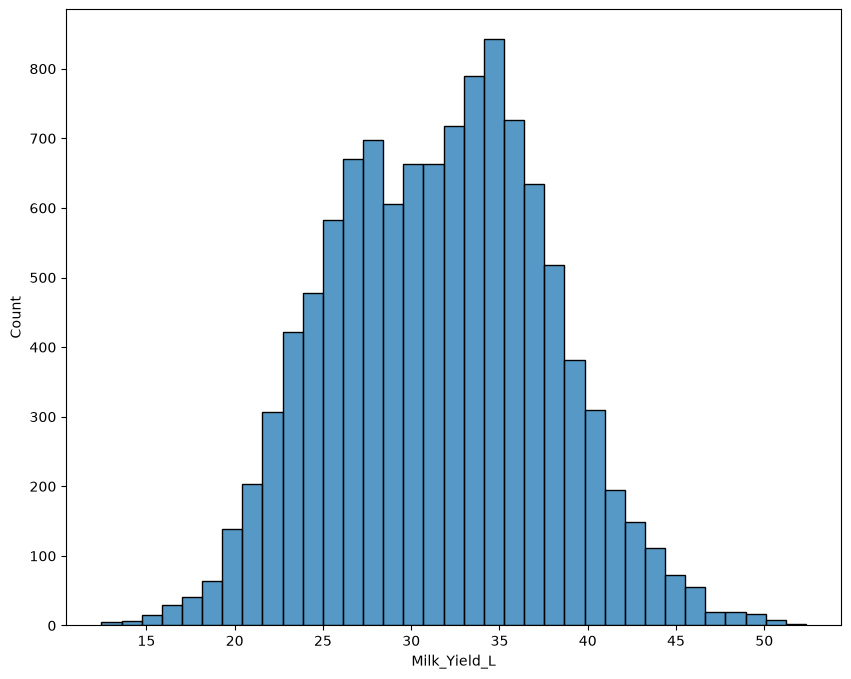

In [357]:
#estudo da variável resposta espsota que é variável contínua

plt.figure(figsize=(10,8))

#gráfico que plota a variável respsota
sns.histplot(df2['Milk_Yield_L'], bins=35)

#### Variáveis Numéricas

array([[<Axes: title={'center': 'Age_Months'}>,
        <Axes: title={'center': 'Weight_kg'}>,
        <Axes: title={'center': 'Parity'}>,
        <Axes: title={'center': 'Days_in_Milk'}>],
       [<Axes: title={'center': 'Feed_Quantity_kg'}>,
        <Axes: title={'center': 'Water_Intake_L'}>,
        <Axes: title={'center': 'Walking_Distance_km'}>,
        <Axes: title={'center': 'Rumination_Time_hrs'}>],
       [<Axes: title={'center': 'Resting_Hours'}>,
        <Axes: title={'center': 'Ambient_Temperature_C'}>,
        <Axes: title={'center': 'Humidity_percent'}>,
        <Axes: title={'center': 'Temperature_Humidity_Index'}>],
       [<Axes: title={'center': 'Previous_Week_Avg_Yield'}>,
        <Axes: title={'center': 'Body_Condition_Score'}>,
        <Axes: title={'center': 'Milking_Frequency_per_day'}>,
        <Axes: title={'center': 'Health_Event_Day'}>],
       [<Axes: title={'center': 'Milk_Yield_L'}>,
        <Axes: title={'center': 'Desvio'}>,
        <Axes: title={'center

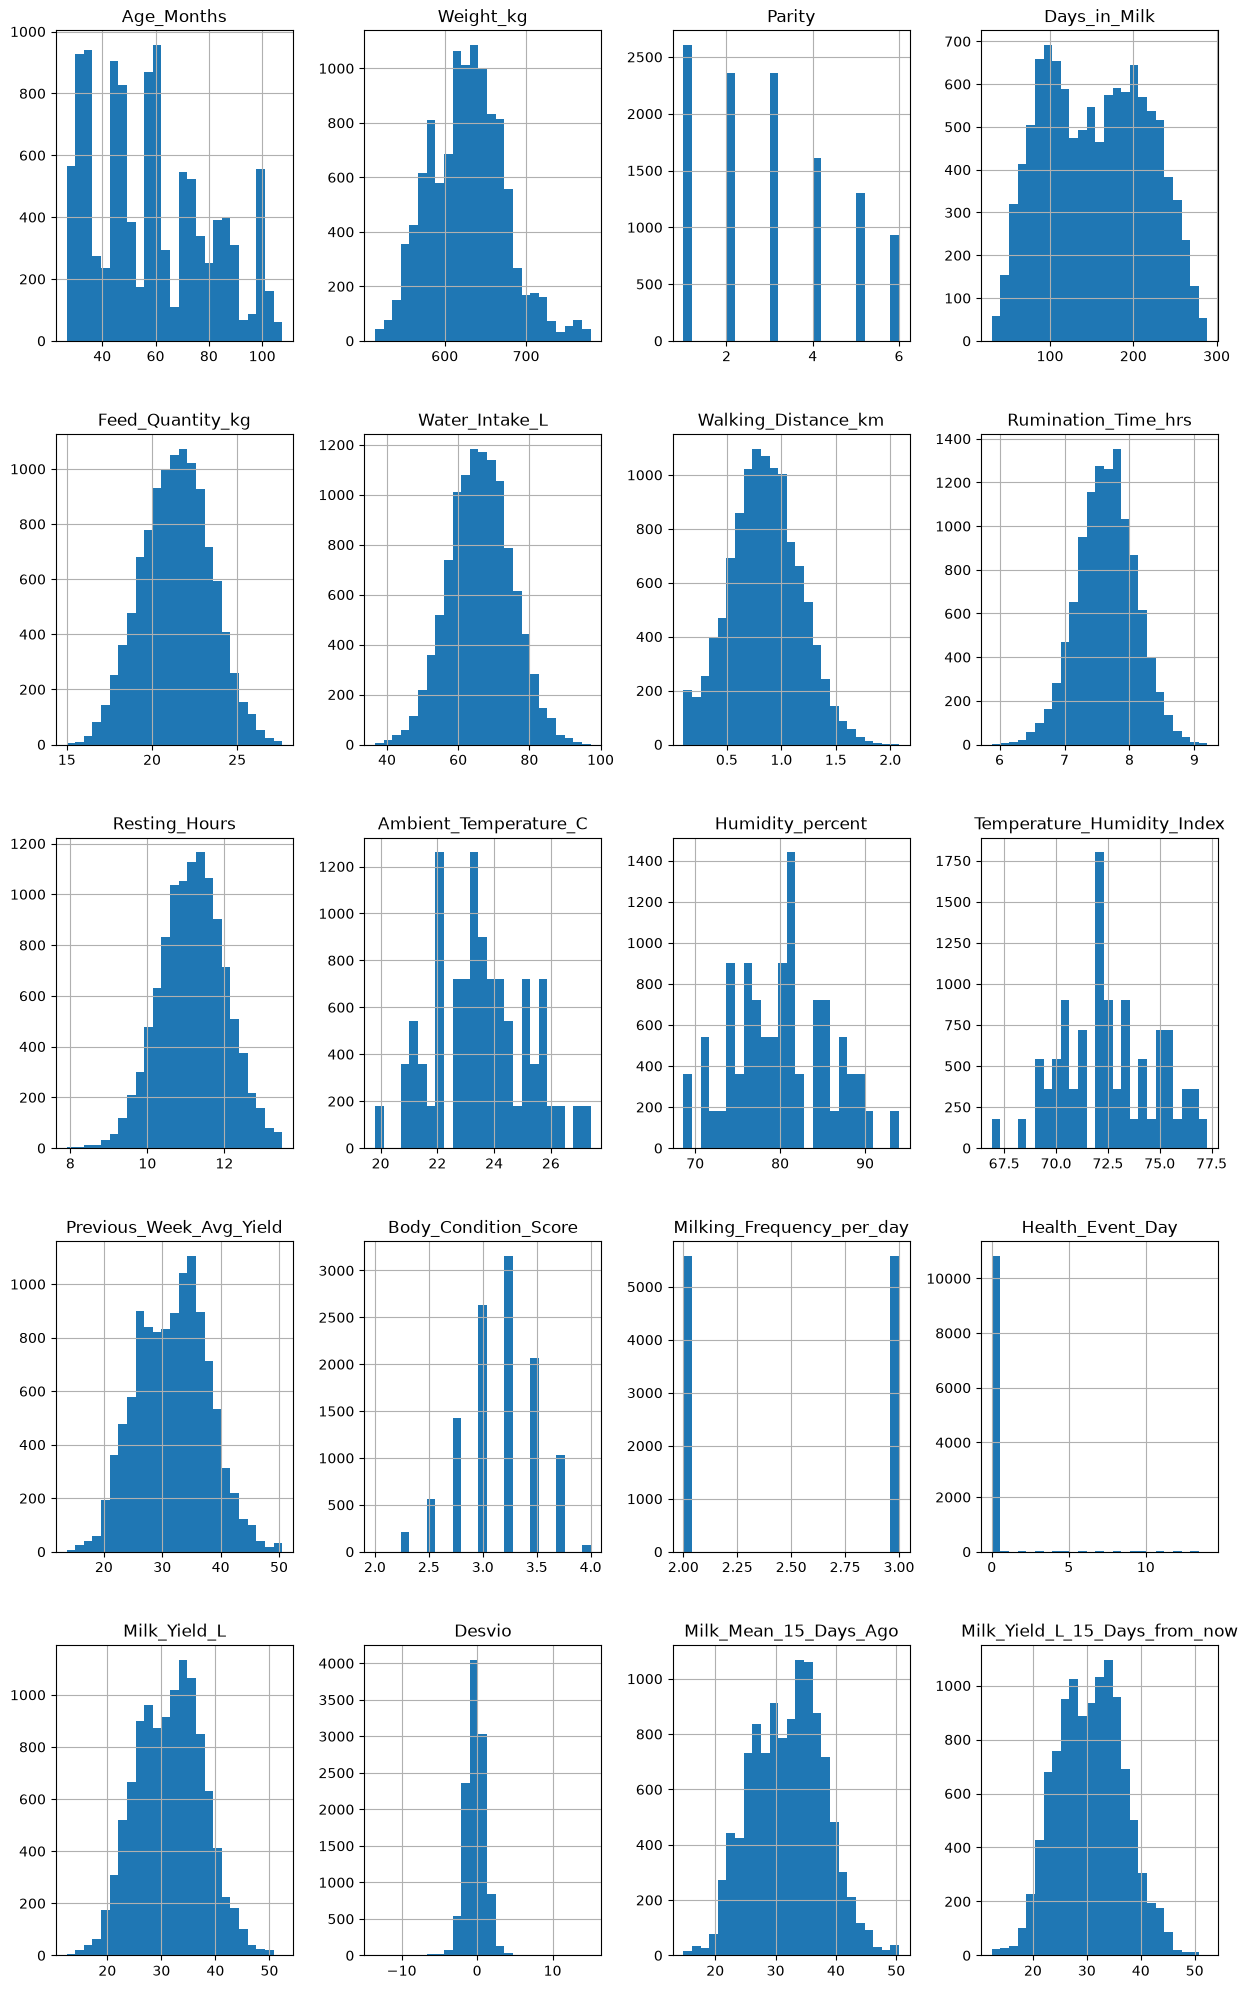

In [358]:
num_atributos.hist(bins = 25, figsize=(15,25))

#### Variáveis Categóricas

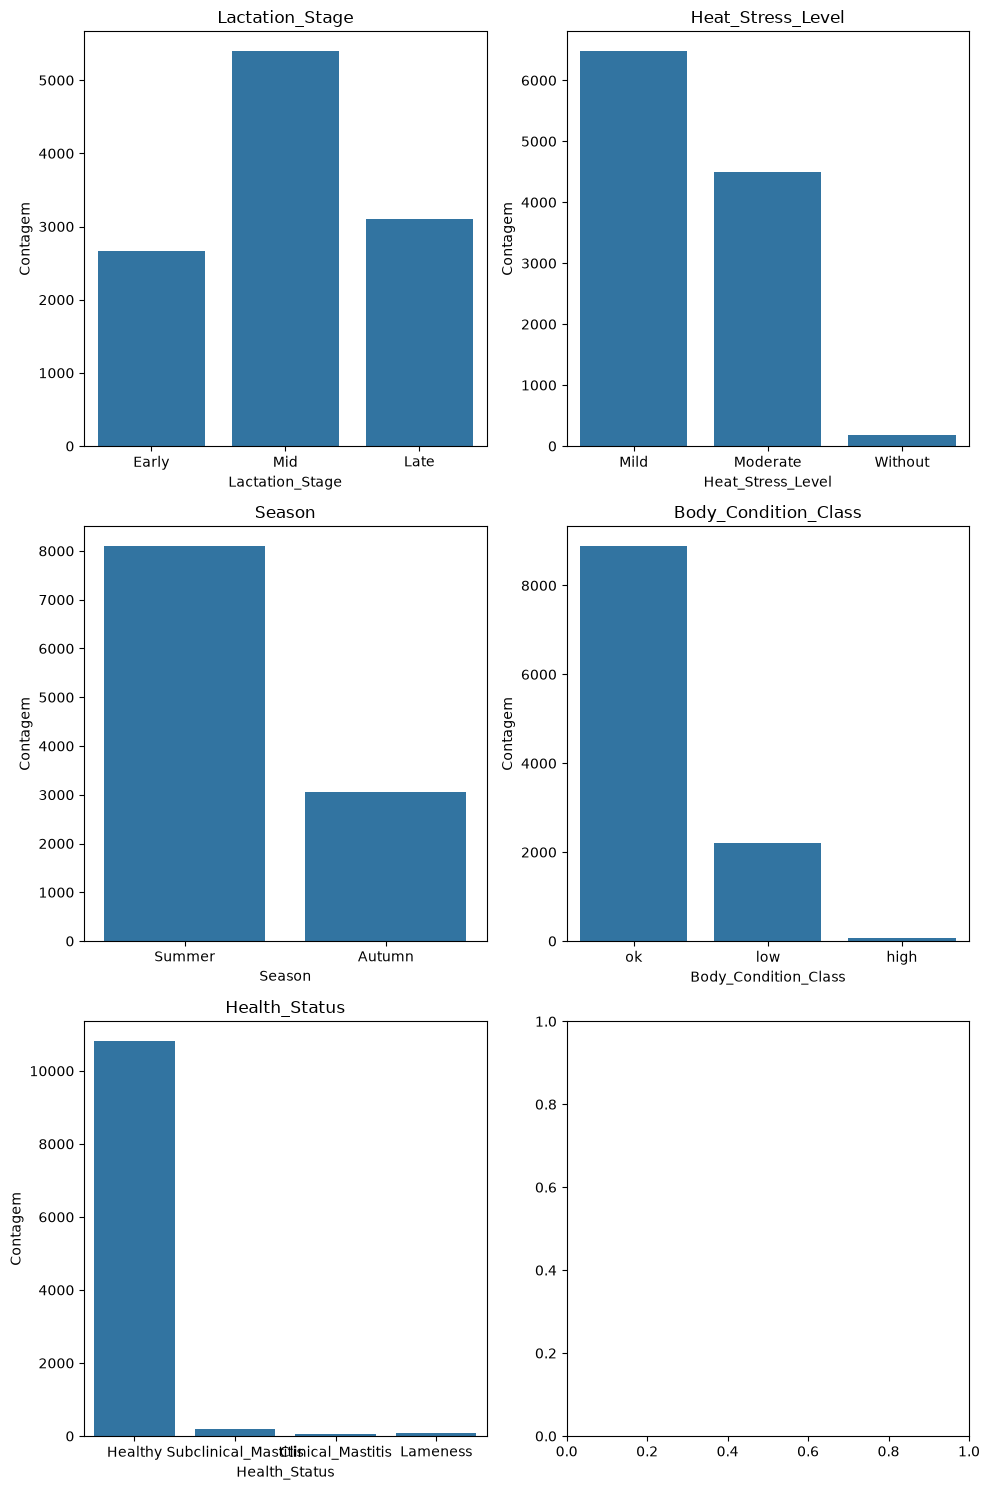

In [359]:
columns = ['Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status']

fig, axes = plt.subplots(3, 2, figsize = (10, 15))

for ax, columns in zip(axes.flat, columns):
    sns.countplot(data = cat_atributos, x = columns, ax = ax)
    ax.set_title(columns)
    ax.set_xlabel(columns)
    ax.set_ylabel('Contagem')

plt.tight_layout()
plt.show()

### Análise Bivariada

<Axes: xlabel='Lactation_Stage', ylabel='Media_Leite'>

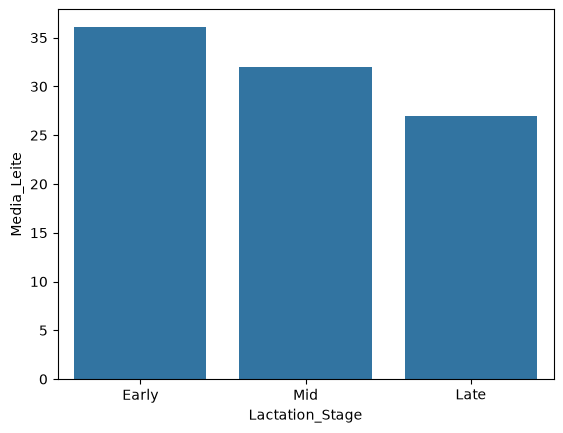

In [360]:
# 1. Vacas com estágio de lactação médio tem maior produtividade diários que vacas com estágio cedo e tardio

aux = df2.groupby('Lactation_Stage')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.barplot(data=aux, x='Lactation_Stage', y='Media_Leite')


<Axes: xlabel='Age_Months', ylabel='Media_Leite'>

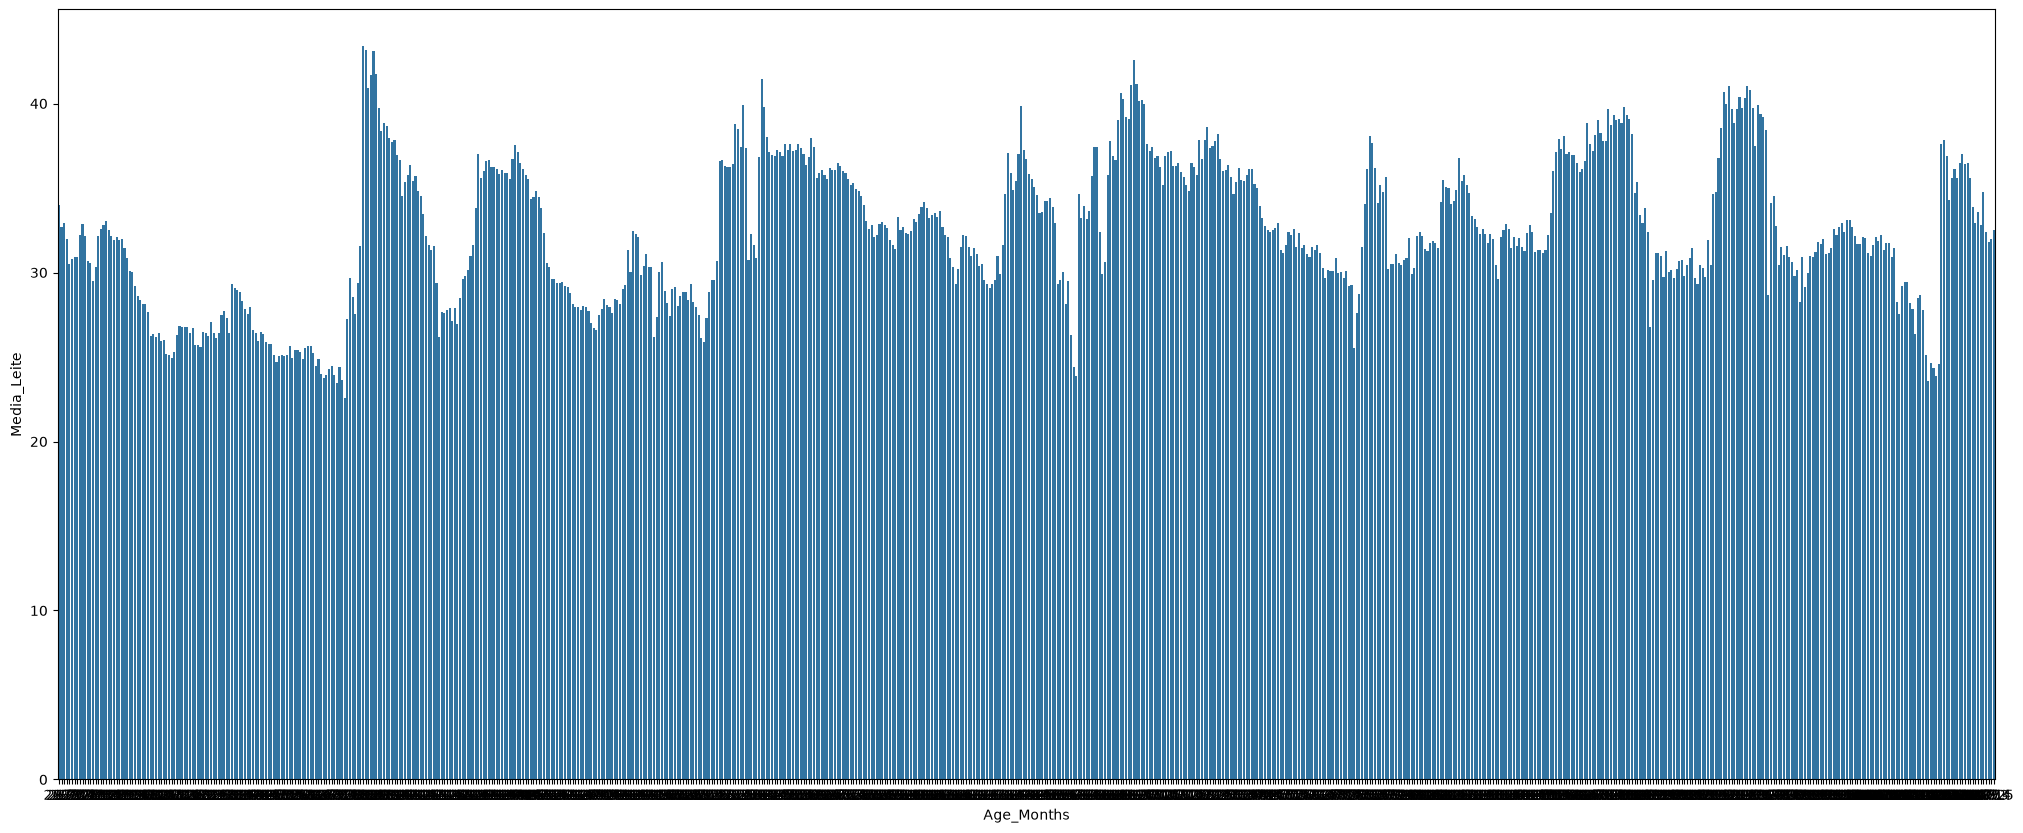

In [361]:
# 2. Vacas com idade mediana produz mais leite que as demais faixas de idade

aux = df2.groupby('Age_Months')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(25, 10))
sns.barplot(data=aux, x='Age_Months', y='Media_Leite')

<Axes: xlabel='Weight_kg', ylabel='Media_Leite'>

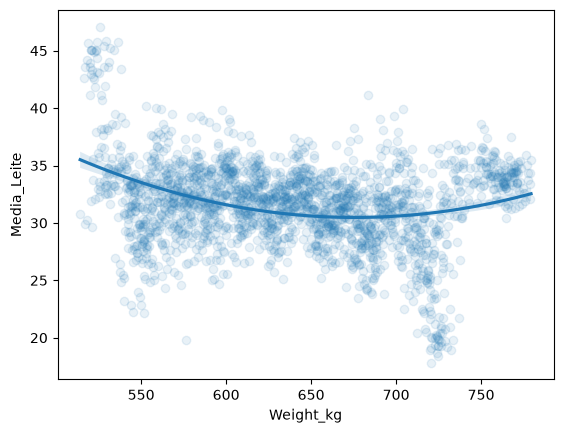

In [362]:
# 3. Vacas mais pesadas tendem a produzir mais leite

aux = df2.groupby('Weight_kg')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.regplot(data=aux, x='Weight_kg', y='Media_Leite', order=2, scatter_kws={'alpha': 0.1})

<Axes: xlabel='Parity', ylabel='Media_Leite'>

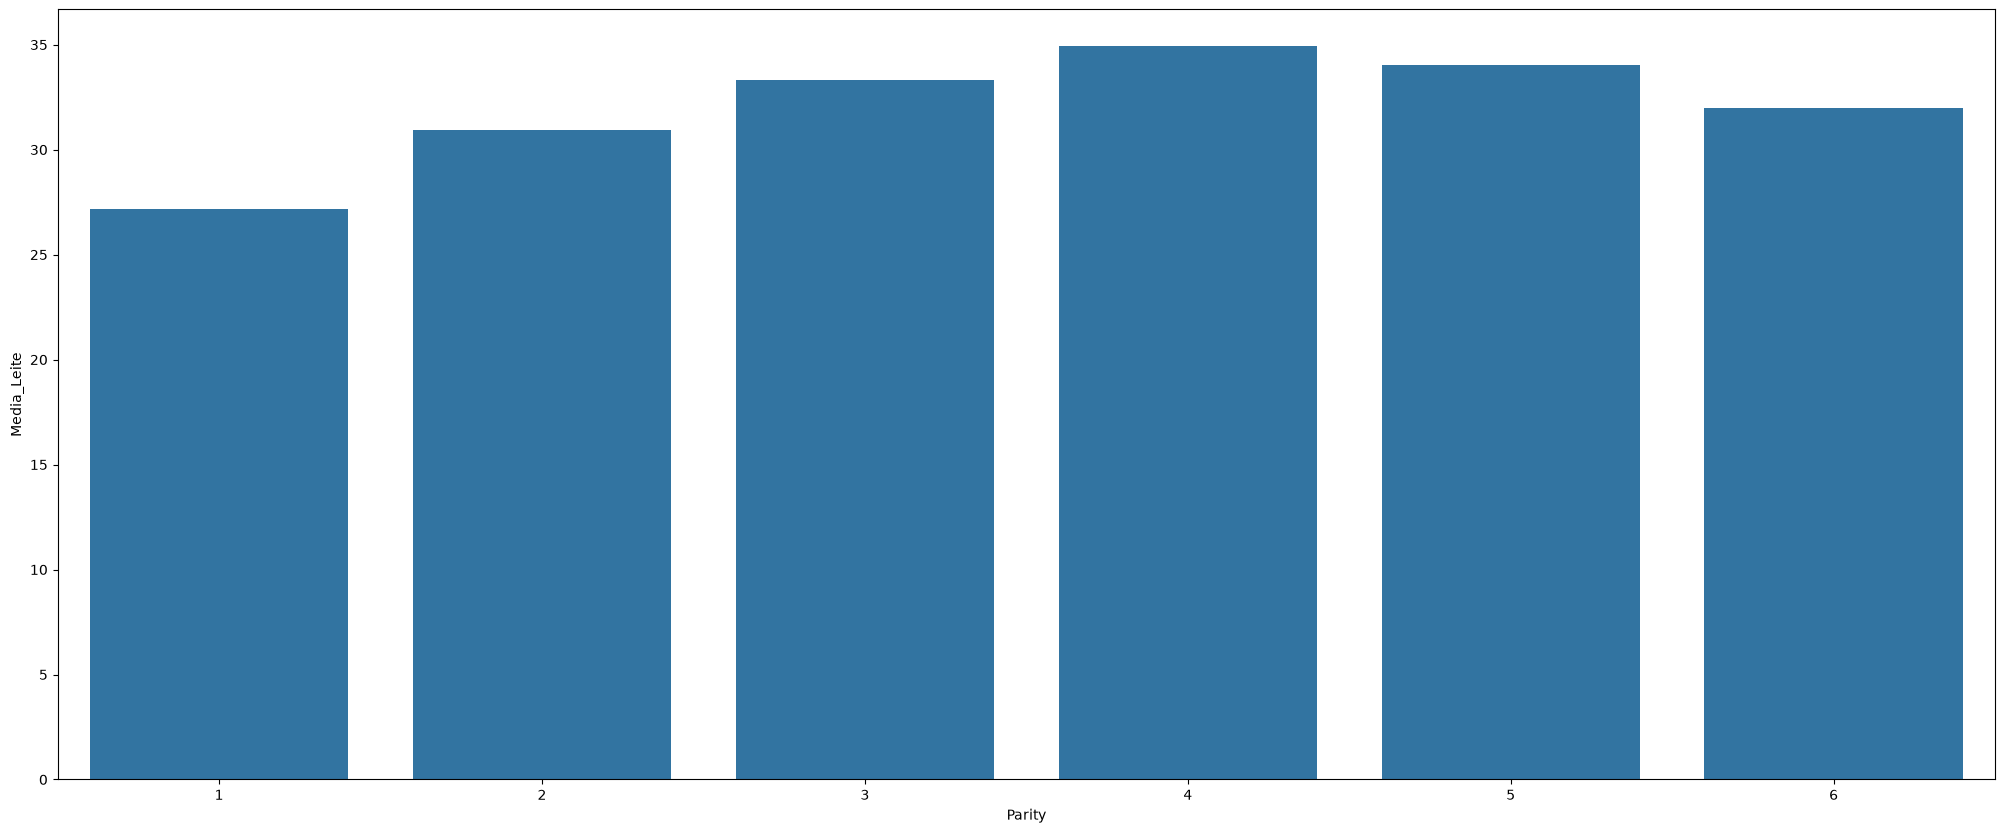

In [363]:
# 4. Vacas com número de partos mediano produz mais leite que as demais faixas de numero de partos

aux = df2.groupby('Parity')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(25, 10))
sns.barplot(data=aux, x='Parity', y='Media_Leite')


<Axes: xlabel='Water_Intake_L', ylabel='Media_Leite'>

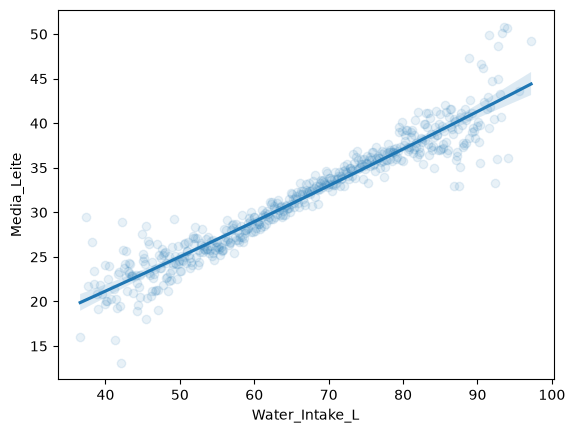

In [364]:
# 5. Vacas que ingerem mais águas produzem mais litros leite diários

aux = df2.groupby('Water_Intake_L')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.regplot(data=aux, x='Water_Intake_L', y='Media_Leite', order=2, scatter_kws={'alpha': 0.1})

<Axes: xlabel='Walking_Distance_km', ylabel='Media_Leite'>

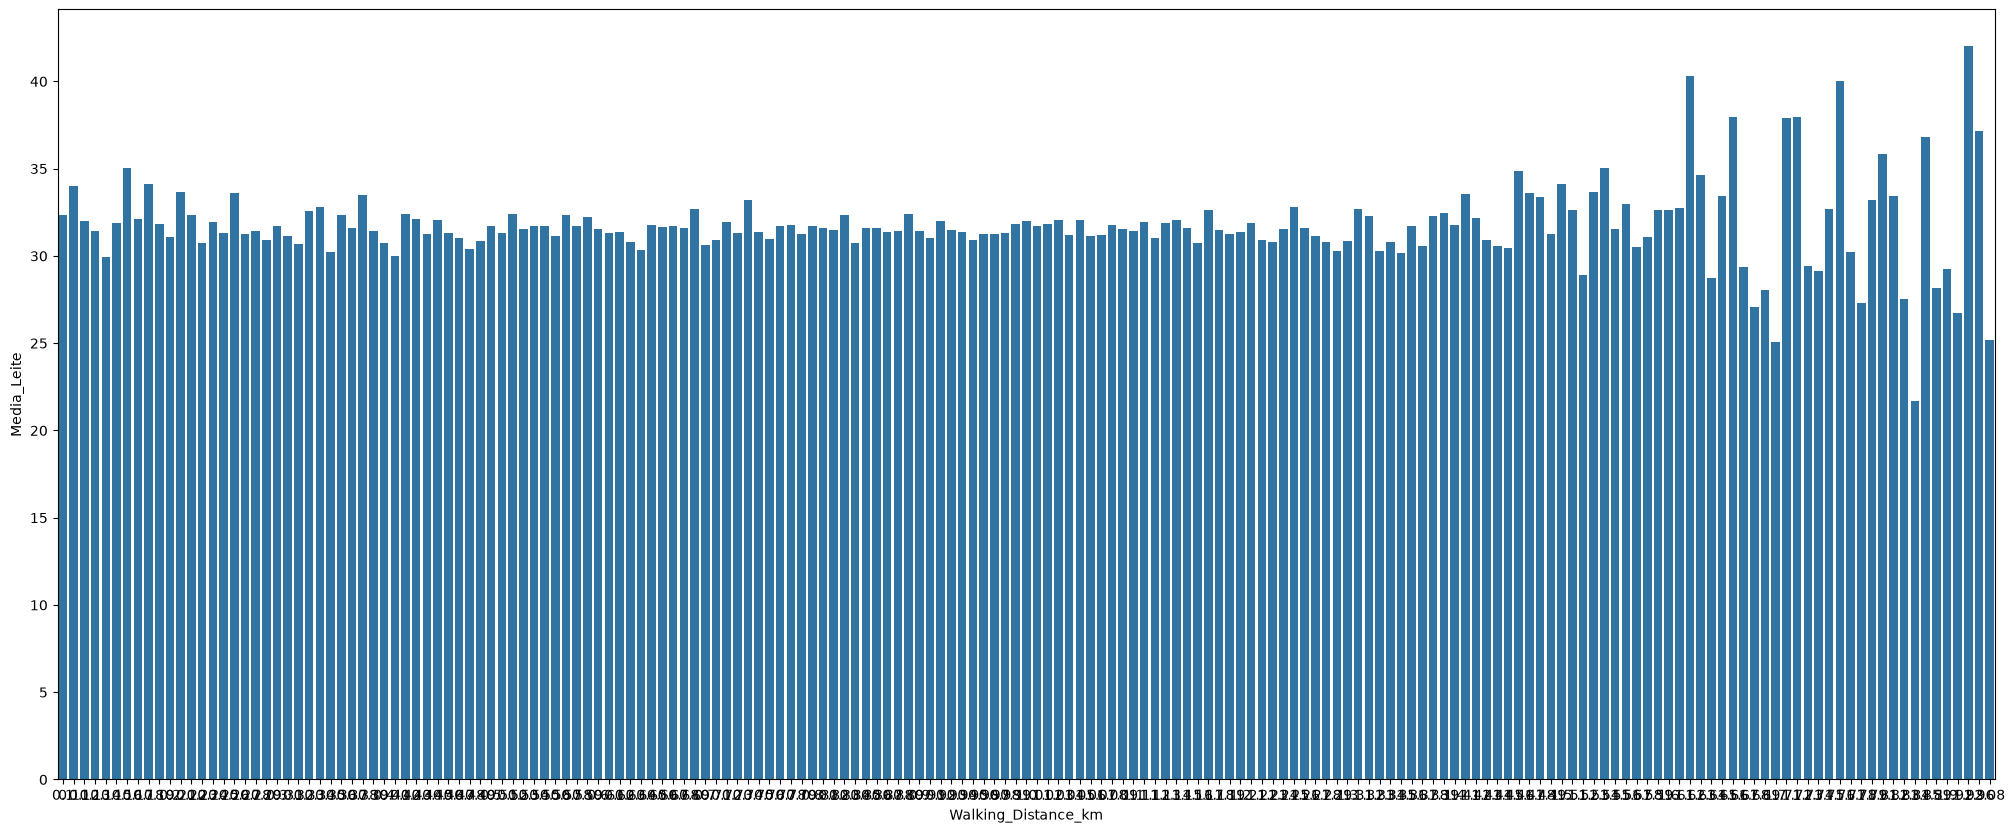

In [365]:
# 6. Vacas que andam mais, produzem menos litros de leite diários

aux = df2.groupby('Walking_Distance_km')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(25, 10))
sns.barplot(data=aux, x='Walking_Distance_km', y='Media_Leite')

<Axes: xlabel='Resting_Hours', ylabel='Media_Leite'>

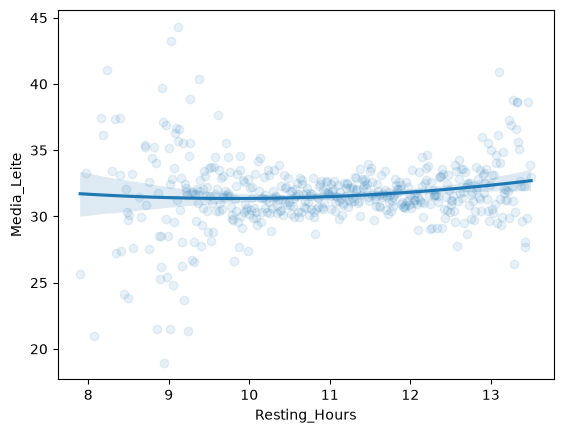

In [366]:
# 7. Vacas que descansam mais tem mais produtividade litros de leite diários

aux = df2.groupby('Resting_Hours')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

sns.regplot(data=aux, x='Resting_Hours', y='Media_Leite', order=2, scatter_kws={'alpha': 0.1})


Season
Summer    8100
Autumn    3060
Name: count, dtype: int64

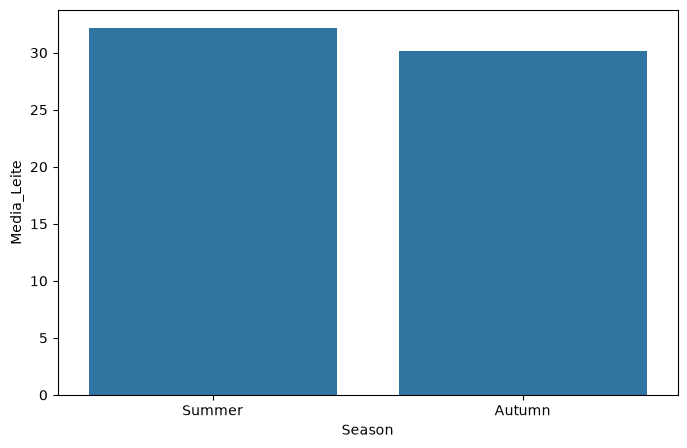

In [367]:
# 8. Vacas no outono produzem mais litros de leite diariamente

aux = df2.groupby('Season')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(8, 5))
sns.barplot(data=aux, x='Season', y='Media_Leite')

df2['Season'].value_counts()

<Axes: xlabel='Previous_Week_Avg_Yield', ylabel='Milk_Yield_L'>

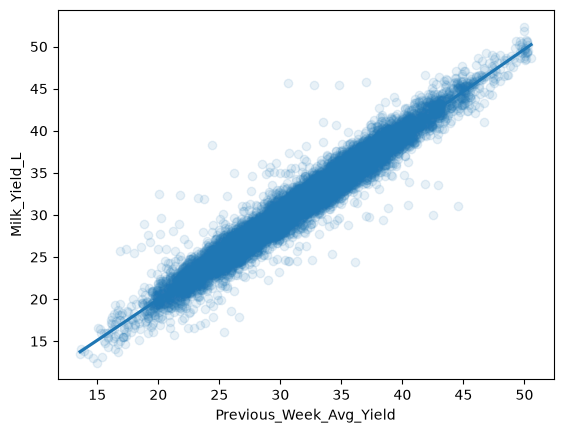

In [368]:
# 9. Na maior parte das vezes, vacas com média diária da semana anterior com maiores produtividades, tendem a produzir maior litros de leite

sns.regplot(data=df2, x='Previous_Week_Avg_Yield', y='Milk_Yield_L', order=2, scatter_kws={'alpha': 0.1})

<Axes: xlabel='Body_Condition_Score', ylabel='Media_Leite'>

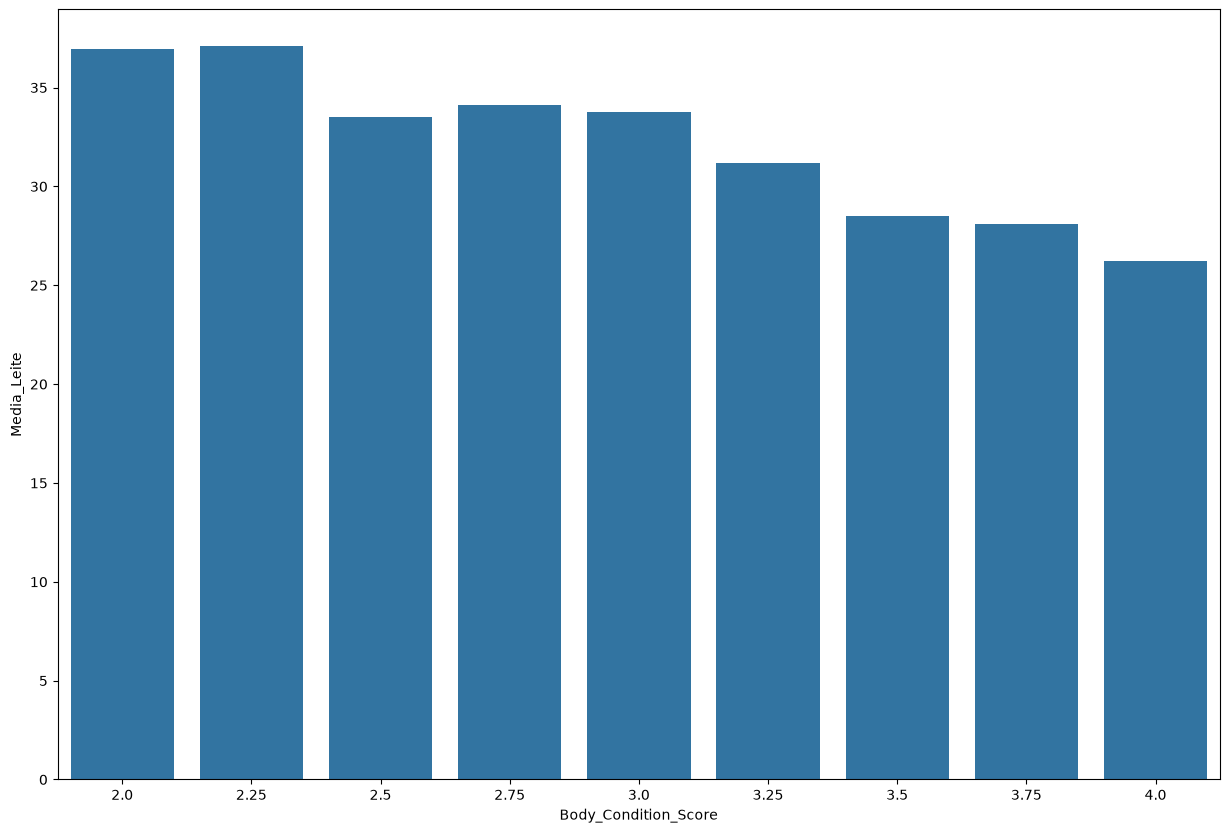

In [369]:
# 10. Vacas com score corporal 3 tendem a ter maior produtividade diária

aux = df2.groupby('Body_Condition_Score')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(15, 10))
sns.barplot(data=aux, x='Body_Condition_Score', y='Media_Leite')

<Axes: xlabel='Milking_Frequency_per_day', ylabel='Media_Leite'>

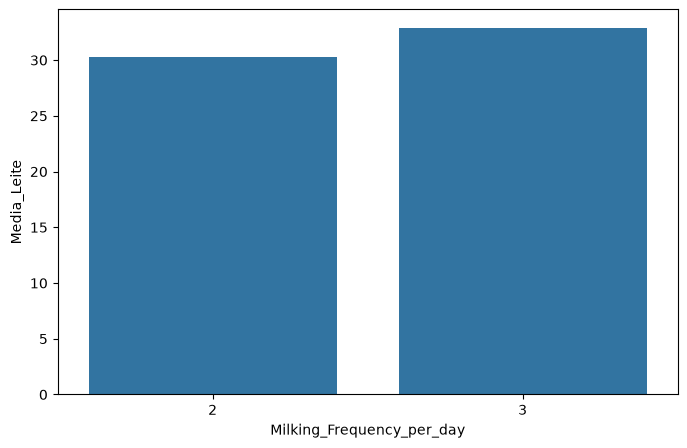

In [370]:
# 11. Vacas com intervalo de ordenha de 8h tendem a ter maior produtividade diária

aux = df2.groupby('Milking_Frequency_per_day')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(8, 5))
sns.barplot(data=aux, x='Milking_Frequency_per_day', y='Media_Leite')


<Axes: xlabel='Health_Status', ylabel='Media_Leite'>

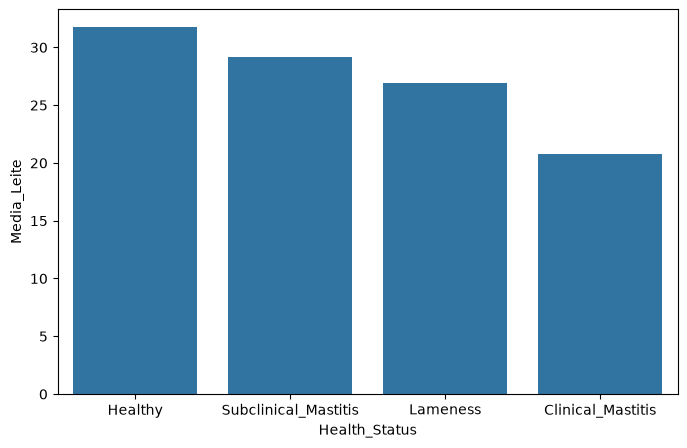

In [371]:
# 12. Vacas saudáveis tendem a produzir mais litros de leite 

aux = df2.groupby('Health_Status')['Milk_Yield_L'].agg(
    Soma_Leite = 'sum',
    Media_Leite = 'mean'
).sort_values(by='Media_Leite', ascending=False).reset_index()
aux

plt.figure(figsize=(8, 5))
sns.barplot(data=aux, x='Health_Status', y='Media_Leite')

<Axes: xlabel='Days_in_Milk', ylabel='Desvio'>

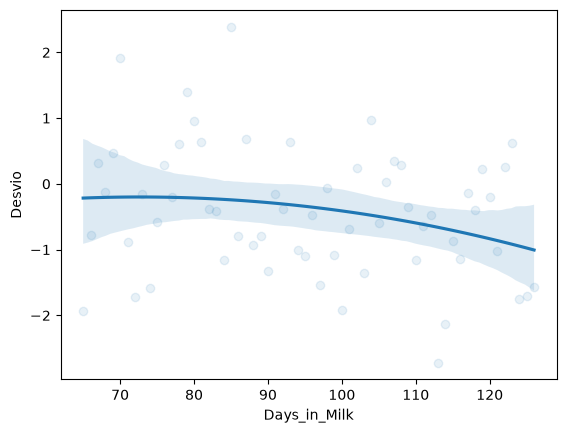

In [372]:
# 13. O desvio de produção aumenta negativamente com avanço do estágio da lactação

aux = df2.loc[df2['Cattle_ID'] == 'CATTLE_0001', :].reset_index()


sns.regplot(data=aux, x='Days_in_Milk', y='Desvio', order=2, scatter_kws={'alpha': 0.1})

<Axes: xlabel='Days_in_Milk', ylabel='Milk_Yield_L'>

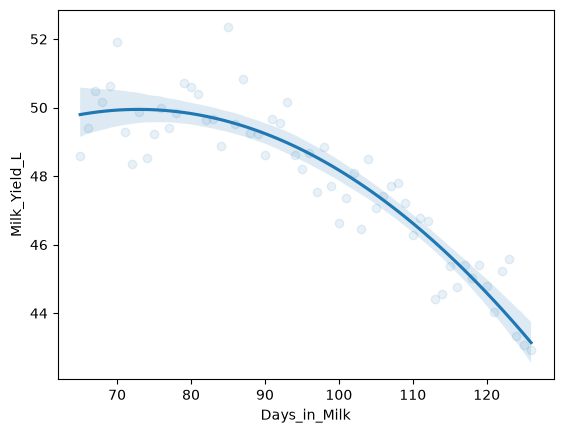

In [373]:
sns.regplot(data=aux, x='Days_in_Milk', y='Milk_Yield_L', order=2, scatter_kws={'alpha': 0.1})

In [374]:
df2.columns

Index(['Cattle_ID', 'Age_Months', 'Weight_kg', 'Parity', 'Lactation_Stage',
       'Days_in_Milk', 'Feed_Quantity_kg', 'Water_Intake_L',
       'Walking_Distance_km', 'Rumination_Time_hrs', 'Resting_Hours',
       'Ambient_Temperature_C', 'Humidity_percent',
       'Temperature_Humidity_Index', 'Heat_Stress_Level', 'Season',
       'Previous_Week_Avg_Yield', 'Body_Condition_Score',
       'Body_Condition_Class', 'Milking_Frequency_per_day', 'Health_Status',
       'Health_Event_Day', 'Date', 'Milk_Yield_L', 'Desvio',
       'Milk_Mean_15_Days_Ago', 'Milk_Yield_L_15_Days_from_now'],
      dtype='str')

1. Vacas com estágio de lactação médio tem maior produtividade diários que vacas com estágio cedo e tardio: Falso. Cedo tem maior produtividade.
2. Vacas com idade mediana produzem mais litros de leite que as demais faixas de idade: Falso. Inconclusivo.
3. Vacas mais pesadas tendem a produzir mais leite: Falso. Inconclusivo.
4. Vacas com número de partos mediano produzem mais litros de leite que as demais faixas de numero de partos: Verdadeiro
5. Vacas que ingerem mais águas produzem mais litros leite diários: Verdadeiro
6. Vacas que andam mais, produzem menos litros de leite diários: Falso. Inconclusivo.
7. Vacas que descansam mais tem mais produtividade litros de leite diários: Falso. Inconclusivo.
8. Vacas no outono produzem mais litros de leite diariamente: Falso. No verão produz mais. 
9. Na maior parte das vezes, vacas com média diária da semana anterior com maiores produtividades, tendem a produzir maior litros de leite. Verdadeiro
10. Vacas com score corporal 3 tendem a ter maior produtividade diária. Falso. Entre 2 e 2.5 tendem a ter maior produtividade.
11. Vacas com intervalo de ordenha de 8h tendem a ter maior produtividade diária: Verdadeiro.
12. Vacas saudáveis tendem a produzir mais litros de leite: Verdadeiro.
13. O desvio de produção aumenta negativamente com avanço do estágio da lactação: Verdadeiro.

In [375]:
resultados = pd.DataFrame({
    'Hipoteses': [i for i in range(1, 14)],
    'Avaliacao': ['F', 'F', 'F', 'V', 'V', 'F', 'F', 'F', 'V', 'F', 'V', 'V', 'V']
})

resultados

,Hipoteses,Avaliacao
0,1,F
1,2,F
2,3,F
3,4,V
4,5,V
5,6,F
6,7,F
7,8,F
8,9,V
9,10,F


### Análise Multivariada

#### Variáveis Numéricas

<Axes: >

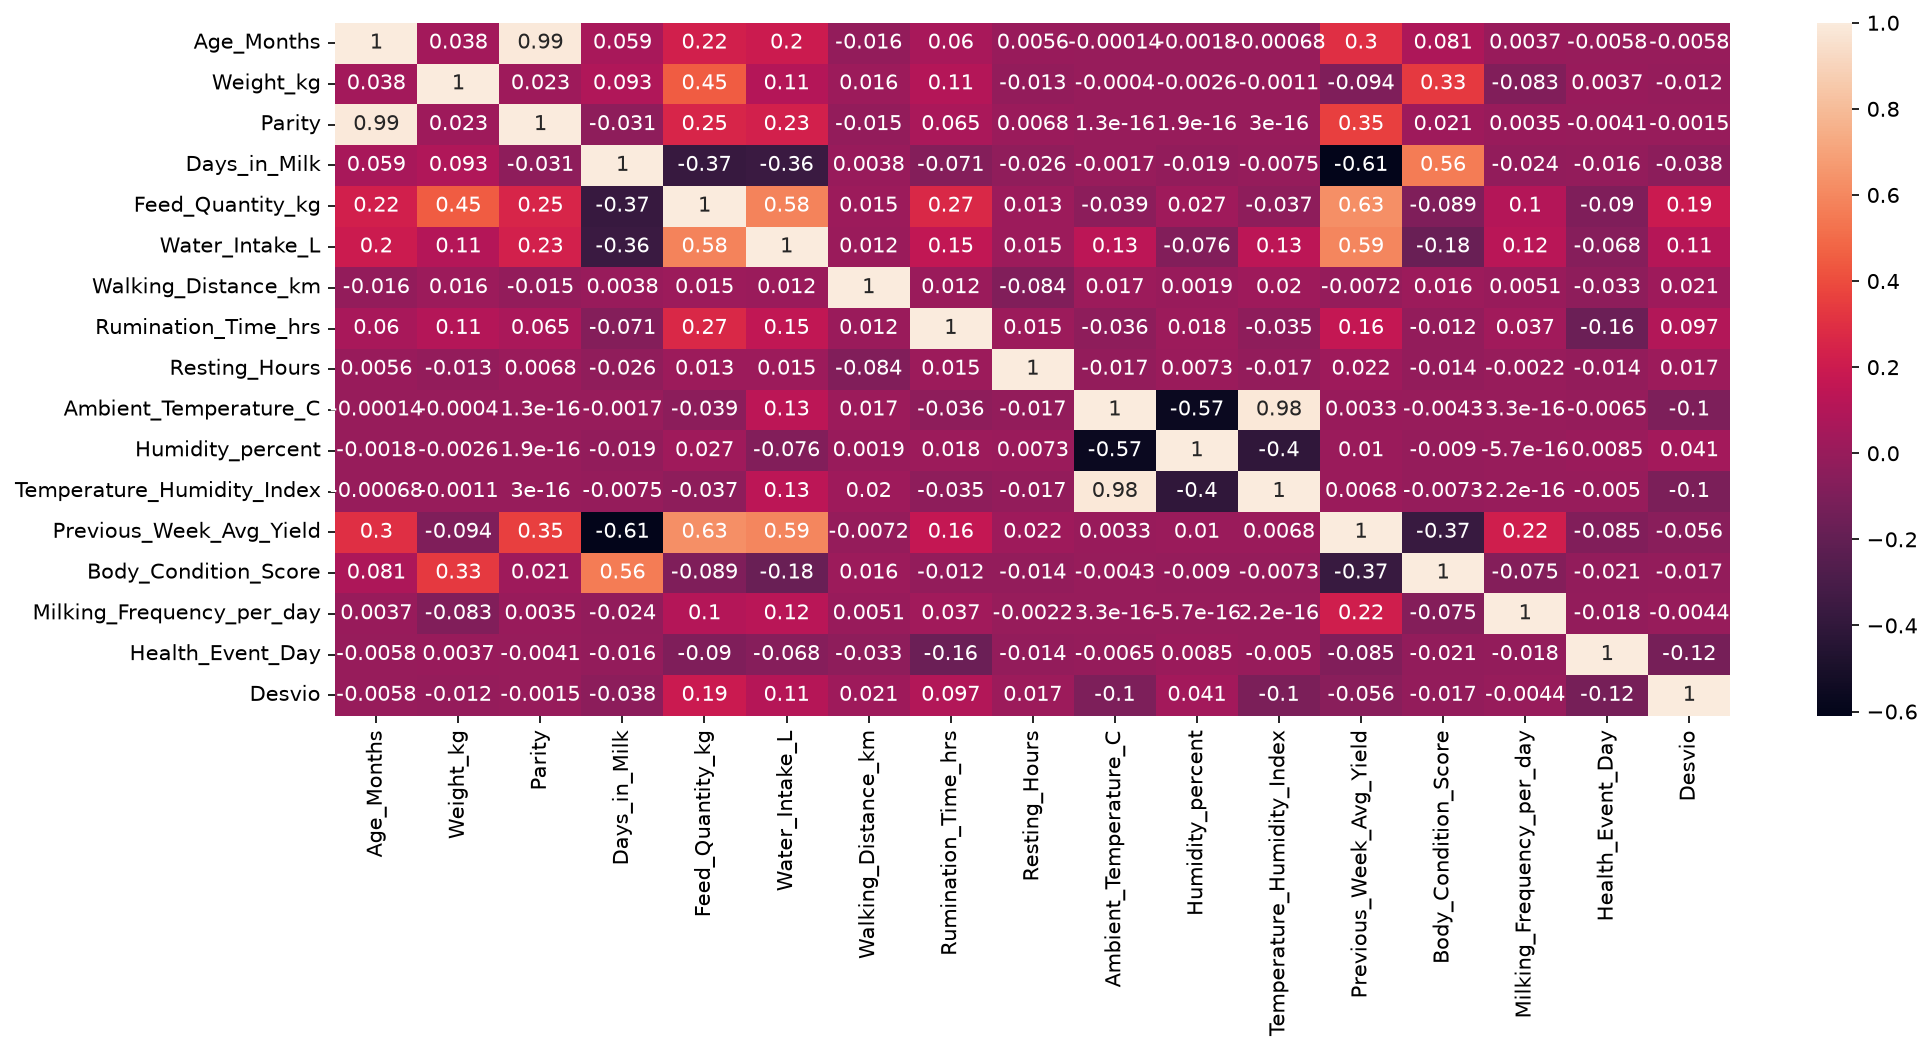

In [376]:
num_atributos_2 = num_atributos.drop(['Milk_Yield_L', 'Milk_Mean_15_Days_Ago', 'Milk_Yield_L_15_Days_from_now'], axis=1)

correlation_matrix = num_atributos_2.corr(method='pearson')

plt.figure(figsize=(15, 6), dpi=150)
sns.heatmap(correlation_matrix, annot=True)

#### Variáveis Categóricas

In [377]:

cat_atributos.columns


Index(['Cattle_ID', 'Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status'],
      dtype='str')

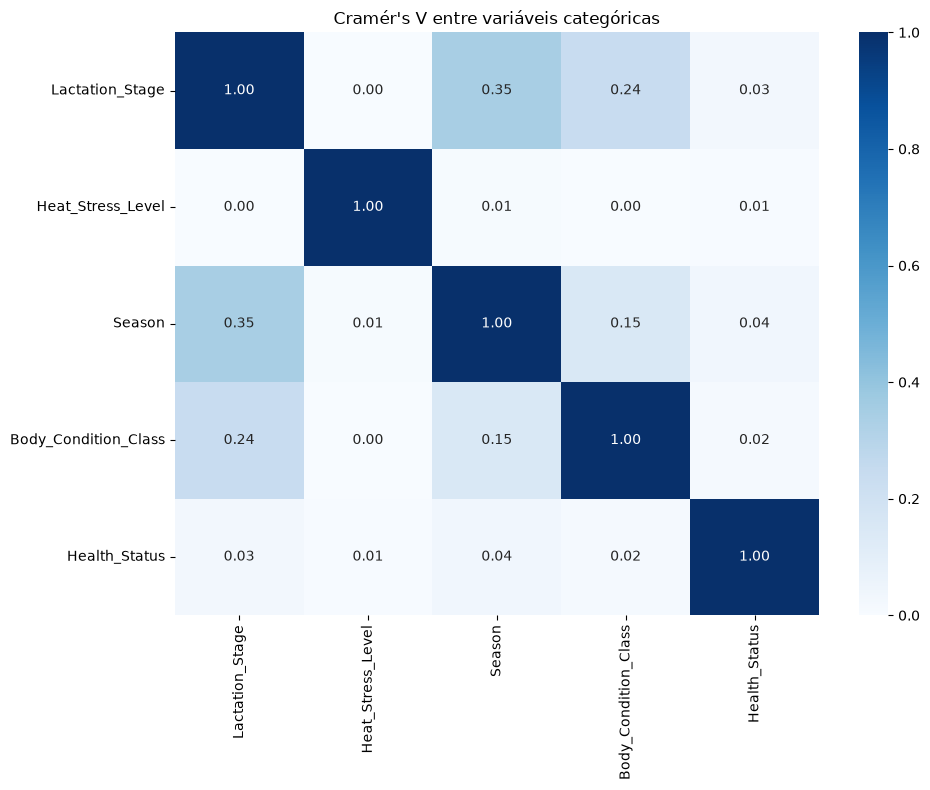

In [378]:
cat_cols = ['Lactation_Stage', 'Heat_Stress_Level', 'Season',
       'Body_Condition_Class', 'Health_Status']

cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramer_matrix.loc[col1, col2] = cramer_v(df[col1], df[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(cramer_matrix.astype(float), annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1)
plt.title("Cramér's V entre variáveis categóricas")
plt.tight_layout()
plt.show()

# Preparação de Dados

In [379]:
aux = df2.loc[df2['Cattle_ID'] == 'CATTLE_0001' , :]
aux.head(15).T


,2700,2880,3060,3240,3420,3600,3780,3960,4140,4320,4500,4680,4860,5040,5220
Cattle_ID,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001,CATTLE_0001
Age_Months,59.1,59.2,59.2,59.2,59.2,59.3,59.3,59.3,59.4,59.4,59.4,59.5,59.5,59.5,59.6
Weight_kg,646.2,648.0,645.9,648.2,641.8,643.2,645.3,645.9,650.8,639.2,643.3,644.9,642.2,643.2,646.4
Parity,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
Lactation_Stage,Early,Early,Early,Early,Early,Early,Early,Early,Early,Early,Early,Early,Early,Early,Early
Days_in_Milk,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79
Feed_Quantity_kg,24.46,26.33,26.93,24.56,25.68,27.47,25.36,26.6,27.35,25.32,26.7,26.37,24.57,25.11,26.81
Water_Intake_L,86.5,73.3,89.2,93.3,94.0,81.6,74.7,81.5,72.9,81.2,75.9,78.3,80.9,91.6,77.8
Walking_Distance_km,0.69,0.33,0.81,0.43,1.13,1.26,0.74,0.21,1.18,1.3,1.04,0.95,0.64,0.96,0.69
Rumination_Time_hrs,7.99,8.36,8.01,8.14,8.0,7.84,7.15,8.23,7.75,7.43,8.29,7.56,7.77,7.69,7.1


In [380]:
# variaveis possiveis: desvio_produtivo = producao atual - media dos ultimos 7 dias